In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cjs-dataset/cjs.csv


In [2]:
data = pd.read_csv('/kaggle/input/cjs-dataset/cjs.csv')
data.head()

,N,TR,TREE,BR,TL,IN,INTERNODE_1,INTERNODE_2,INTERNODE_3,INTERNODE_4,...,INTERNODE_20,INTERNODE_21,INTERNODE_22,INTERNODE_23,INTERNODE_24,INTERNODE_25,INTERNODE_26,INTERNODE_27,INTERNODE_28,INTERNODE_29
0,1,control,G28,A,75.0,15,1.0,2.3,7.4,8.6,...,?,?,?,?,?,?,?,?,?,?
1,2,control,G28,B,18.0,7,0.7,1.3,4.0,5.2,...,?,?,?,?,?,?,?,?,?,?
2,3,control,G28,C,46.0,11,0.5,1.0,4.3,8.8,...,?,?,?,?,?,?,?,?,?,?
3,4,control,G28,C,16.0,8,0.5,1.2,3.5,4.2,...,?,?,?,?,?,?,?,?,?,?
4,5,control,G28,D,56.0,16,0.5,1.0,3.5,8.2,...,?,?,?,?,?,?,?,?,?,?


In [3]:
data.isnull().sum()

N               0
TR              0
TREE            0
BR              0
TL              0
IN              0
INTERNODE_1     0
INTERNODE_2     0
INTERNODE_3     0
INTERNODE_4     0
INTERNODE_5     0
INTERNODE_6     0
INTERNODE_7     0
INTERNODE_8     0
INTERNODE_9     0
INTERNODE_10    0
INTERNODE_11    0
INTERNODE_12    0
INTERNODE_13    0
INTERNODE_14    0
INTERNODE_15    0
INTERNODE_16    0
INTERNODE_17    0
INTERNODE_18    0
INTERNODE_19    0
INTERNODE_20    0
INTERNODE_21    0
INTERNODE_22    0
INTERNODE_23    0
INTERNODE_24    0
INTERNODE_25    0
INTERNODE_26    0
INTERNODE_27    0
INTERNODE_28    0
INTERNODE_29    0
dtype: int64

In [4]:
data.replace('?', np.nan, inplace=True)


In [5]:
data.head()

,N,TR,TREE,BR,TL,IN,INTERNODE_1,INTERNODE_2,INTERNODE_3,INTERNODE_4,...,INTERNODE_20,INTERNODE_21,INTERNODE_22,INTERNODE_23,INTERNODE_24,INTERNODE_25,INTERNODE_26,INTERNODE_27,INTERNODE_28,INTERNODE_29
0,1,control,G28,A,75.0,15,1.0,2.3,7.4,8.6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,control,G28,B,18.0,7,0.7,1.3,4.0,5.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,control,G28,C,46.0,11,0.5,1.0,4.3,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,control,G28,C,16.0,8,0.5,1.2,3.5,4.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,control,G28,D,56.0,16,0.5,1.0,3.5,8.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convertir les colonnes INTERNODE en float
internode_cols = [col for col in data.columns if col.startswith('INTERNODE')]
data[internode_cols] = data[internode_cols].astype(float)


In [7]:
#Gérer les valeurs manquantes (NaN) -> Remplir avec les valeurs moyenne
data[internode_cols] = data[internode_cols].fillna(data[internode_cols].mean())


In [8]:
from sklearn.preprocessing import OrdinalEncoder

cat_cols = data.select_dtypes(include='object').columns
encoder = OrdinalEncoder()
data[cat_cols] = encoder.fit_transform(data[cat_cols])


In [9]:
data.head()

,N,TR,TREE,BR,TL,IN,INTERNODE_1,INTERNODE_2,INTERNODE_3,INTERNODE_4,...,INTERNODE_20,INTERNODE_21,INTERNODE_22,INTERNODE_23,INTERNODE_24,INTERNODE_25,INTERNODE_26,INTERNODE_27,INTERNODE_28,INTERNODE_29
0,1,4.0,15.0,0.0,75.0,15,1.0,2.3,7.4,8.6,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
1,2,4.0,15.0,1.0,18.0,7,0.7,1.3,4.0,5.2,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
2,3,4.0,15.0,2.0,46.0,11,0.5,1.0,4.3,8.8,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
3,4,4.0,15.0,2.0,16.0,8,0.5,1.2,3.5,4.2,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
4,5,4.0,15.0,3.0,56.0,16,0.5,1.0,3.5,8.2,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3


In [10]:
data.isnull().sum()

N                0
TR               0
TREE             0
BR              12
TL               0
IN               0
INTERNODE_1      0
INTERNODE_2      0
INTERNODE_3      0
INTERNODE_4      0
INTERNODE_5      0
INTERNODE_6      0
INTERNODE_7      0
INTERNODE_8      0
INTERNODE_9      0
INTERNODE_10     0
INTERNODE_11     0
INTERNODE_12     0
INTERNODE_13     0
INTERNODE_14     0
INTERNODE_15     0
INTERNODE_16     0
INTERNODE_17     0
INTERNODE_18     0
INTERNODE_19     0
INTERNODE_20     0
INTERNODE_21     0
INTERNODE_22     0
INTERNODE_23     0
INTERNODE_24     0
INTERNODE_25     0
INTERNODE_26     0
INTERNODE_27     0
INTERNODE_28     0
INTERNODE_29     0
dtype: int64

In [11]:
data.drop(['BR'], axis=1)

,N,TR,TREE,TL,IN,INTERNODE_1,INTERNODE_2,INTERNODE_3,INTERNODE_4,INTERNODE_5,...,INTERNODE_20,INTERNODE_21,INTERNODE_22,INTERNODE_23,INTERNODE_24,INTERNODE_25,INTERNODE_26,INTERNODE_27,INTERNODE_28,INTERNODE_29
0,1,4.0,15.0,75.0,15,1.0,2.3,7.4,8.600000,6.700000,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
1,2,4.0,15.0,18.0,7,0.7,1.3,4.0,5.200000,2.800000,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
2,3,4.0,15.0,46.0,11,0.5,1.0,4.3,8.800000,6.800000,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
3,4,4.0,15.0,16.0,8,0.5,1.2,3.5,4.200000,2.200000,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
4,5,4.0,15.0,56.0,16,0.5,1.0,3.5,8.200000,5.300000,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2791,2792,1.0,13.0,1.0,4,0.3,0.3,0.3,0.300000,3.645922,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
2792,2793,1.0,13.0,1.0,4,0.3,0.3,0.3,0.300000,3.645922,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
2793,2794,1.0,13.0,1.0,4,0.3,0.3,0.3,0.300000,3.645922,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3
2794,2795,1.0,13.0,1.0,4,0.2,0.2,0.2,0.200000,3.645922,...,1.544186,1.423077,1.188235,0.95,0.842857,0.95,2.2,1.2,0.9,0.3


In [12]:
X = data.drop(['TR'], axis=1)
y = data['TR']

In [13]:
# Pour chaque colonne catégorielle, on vérifie si elle est fortement liée à la classe TR
cat_cols = ['TREE', 'IN', 'TL']  # ajuste selon ton dataset

for col in cat_cols:
    print(f"Colonne: {col}")
    print(data.groupby('TR')[col].nunique())
    print("\n")


Colonne: TREE
TR
0.0     9
1.0     9
2.0    10
3.0    10
4.0     9
5.0    10
Name: TREE, dtype: int64


Colonne: IN
TR
0.0    20
1.0    24
2.0    21
3.0    26
4.0    21
5.0    24
Name: IN, dtype: int64


Colonne: TL
TR
0.0    42
1.0    47
2.0    36
3.0    81
4.0    87
5.0    90
Name: TL, dtype: int64




In [14]:
cols_to_drop = ['TREE', 'BR']  # adapte selon analyse

X = data.drop(cols_to_drop + ['TR'], axis=1)
y = data['TR']



In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd


# Étape 2 : split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.3, random_state=500)

# Étape 3 : définir les modèles
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=500),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=500),
    'SVC (RBF)': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, random_state=500)),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=808))
}

# Étape 4 : entraînement et évaluation
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    
    results.append({
        'Modèle': name,
        'Train Accuracy': round(train_acc, 4),
        'Test Accuracy': round(test_acc, 4)
    })

# Étape 5 : afficher les résultats
results_df = pd.DataFrame(results)
print(results_df.sort_values(by="Test Accuracy", ascending=False))


                Modèle  Train Accuracy  Test Accuracy
0        Decision Tree          1.0000         0.9959
1        Random Forest          1.0000         0.9535
4  Logistic Regression          0.9356         0.8774
2            SVC (RBF)          0.9105         0.8340
3                  KNN          0.8437         0.7942


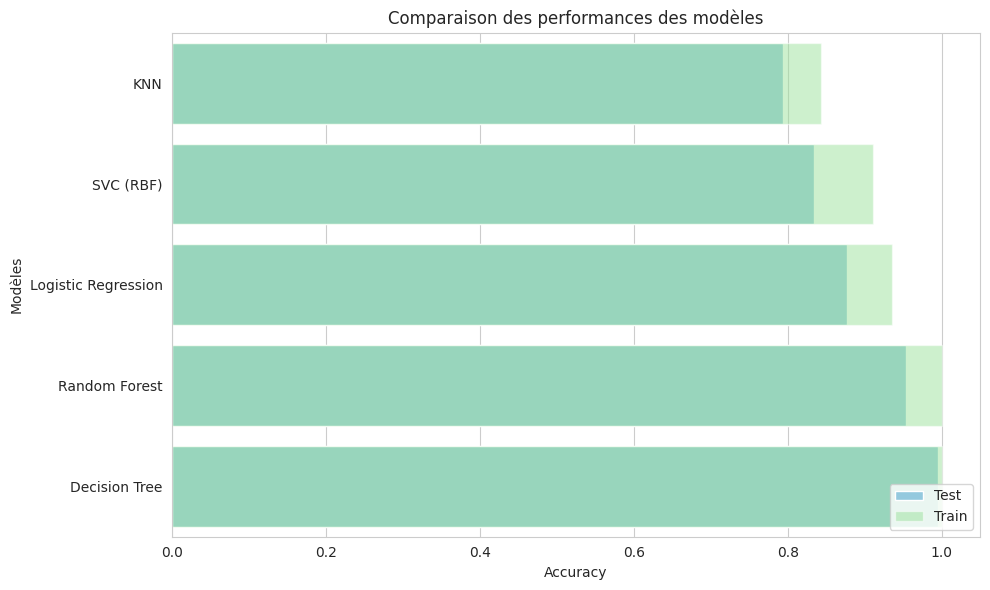

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tri des résultats pour meilleur affichage
results_df_sorted = results_df.sort_values(by='Test Accuracy', ascending=True)

# Création du graphique
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Barplot des performances test
sns.barplot(data=results_df_sorted, x='Test Accuracy', y='Modèle', color='skyblue', label='Test')
sns.barplot(data=results_df_sorted, x='Train Accuracy', y='Modèle', color='lightgreen', label='Train', alpha=0.5)

plt.title('Comparaison des performances des modèles')
plt.xlabel('Accuracy')
plt.ylabel('Modèles')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

KNN et Decision Tree : Apprennent trop bien les données d'entraînement. Fort risque de surapprentissage → mauvaise généralisation possible sur des données nouvelles.

Random Forest : Très bon équilibre. Léger écart entre train et test → bonne capacité de généralisation, tout en gardant une bonne performance.

SVC : Moins performant ici, mais plus réaliste.

In [17]:
from sklearn.metrics import roc_auc_score
train_auc = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')
test_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
print("train",train_auc)
print("test", test_auc)

train 0.9953512329776716
test 0.976592368367856


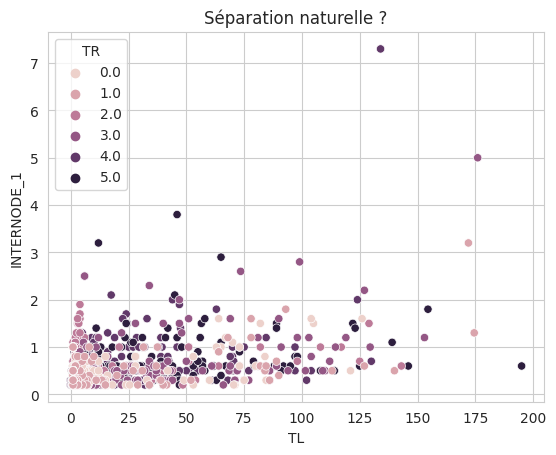

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exemple : TL vs INTERNODE_1 coloré par TR
sns.scatterplot(data=data, x='TL', y='INTERNODE_1', hue='TR')
plt.title("Séparation naturelle ?")
plt.show()


In [19]:
results_df.to_csv("comparaison_modeles.csv", index=False)
